# Sales Prediction (Simple Linear Regression)

Problem Statement:  Build a model which predicts sales (thosands of units) based on the money spent (in thousands of dollers) on different platforms for marketing.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
advertising = pd.read_csv("/Users/vydhyamvishnusai/SALES_PREDICTION_SLR/Advertising.csv", index_col = 0)
advertising.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


# Data Cleaning

In [4]:
advertising.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

# Outlier Analysis

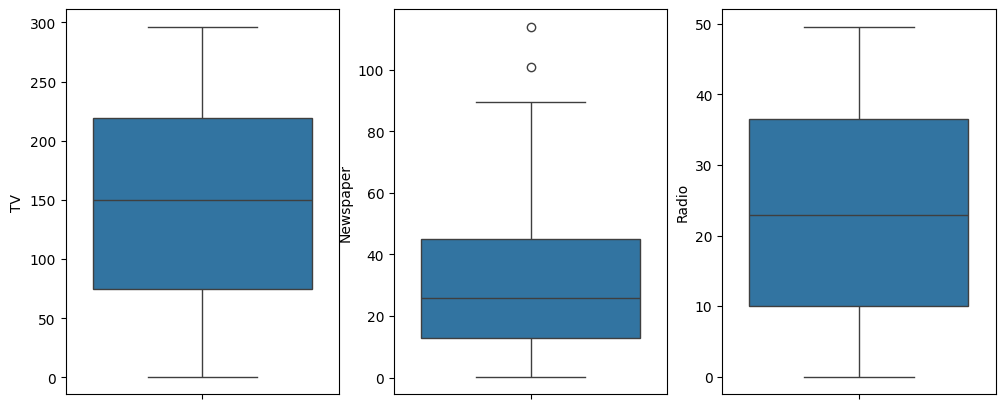

In [5]:
plt.figure(figsize = (12,5))

plt.subplot(1,3,1)
plt1 = sns.boxplot(advertising['TV'])
plt.subplot(1,3,2)
plt2 = sns.boxplot(advertising['Newspaper'])
plt.subplot(1,3,3)
plt3 = sns.boxplot(advertising['Radio'])

# EDA

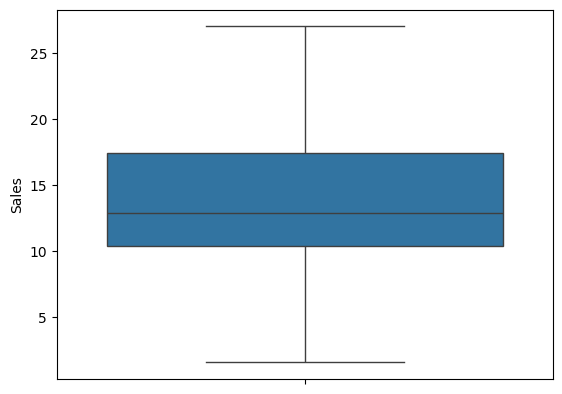

In [6]:
sns.boxplot(advertising['Sales'])
plt.show()

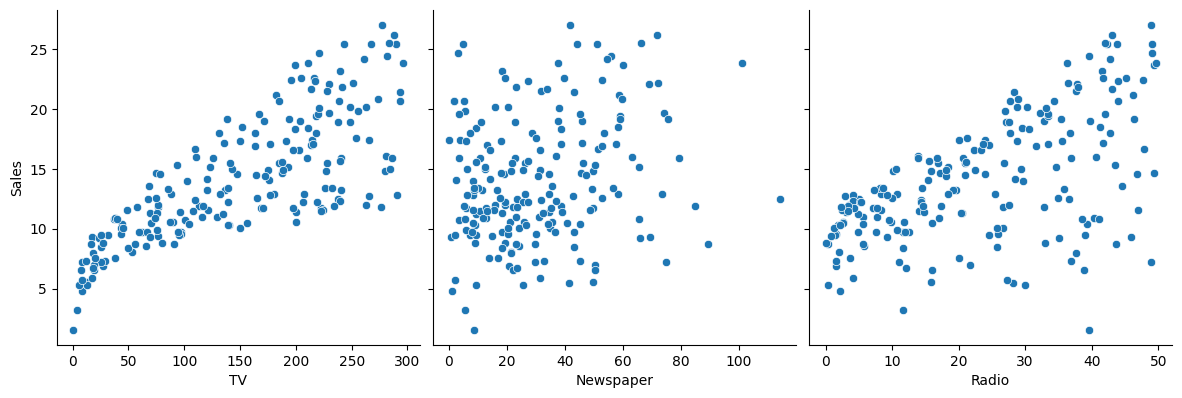

In [7]:
sns.pairplot(advertising, x_vars = ['TV', 'Newspaper', 'Radio'], y_vars = 'Sales', height = 4, aspect = 1, kind = 'scatter')
plt.show()

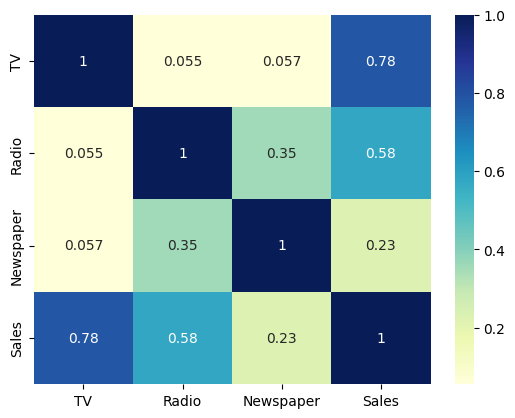

In [8]:
sns.heatmap(advertising.corr(), cmap = "YlGnBu", annot = True)
plt.show()

# Model Building

# Simple Linear Regression

In [9]:
x = advertising['TV']
y = advertising['Sales']

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state= 42)

In [11]:
x_train.head()

80     116.0
198    177.0
39      43.1
25      62.3
123    224.0
Name: TV, dtype: float64

In [12]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160,)
(40,)
(160,)
(40,)


# Building Linear Model

In [13]:
!pip install statsmodels

In [14]:
import statsmodels.api as sm

In [15]:
x_train_sm = sm.add_constant(x_train) #Here it will add a constant to get an intercept 
lr = sm.OLS(y_train,x_train_sm).fit()

In [16]:
x_train_sm.head()

,const,TV
80,1.0,116.0
198,1.0,177.0
39,1.0,43.1
25,1.0,62.3
123,1.0,224.0


In [17]:
lr.params #it will prints the intercept and the slope of the regression line fitted

const    7.119638
TV       0.046530
dtype: float64

In [18]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     228.5
Date:                Thu, 28 May 2026   Prob (F-statistic):           1.68e-32
Time:                        21:31:12   Log-Likelihood:                -415.93
No. Observations:                 160   AIC:                             835.9
Df Residuals:                     158   BIC:                             842.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1196      0.530     13.446      0.0

# Observations

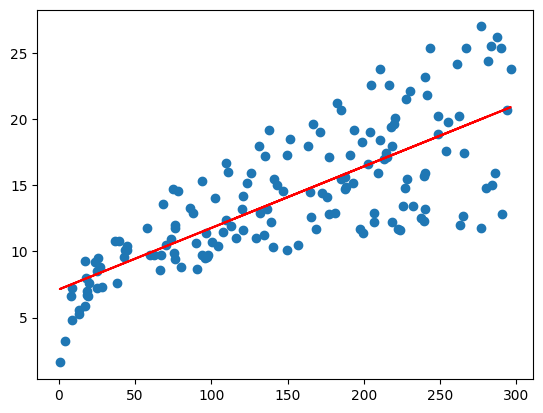

In [19]:
plt.scatter(x_train,y_train)
plt.plot(x_train, 7.1196 + 0.0465*x_train, 'r')
plt.show()

# Model Evaluation

In [20]:
y_train_pred = lr.predict(x_train_sm)
res = (y_train - y_train_pred)

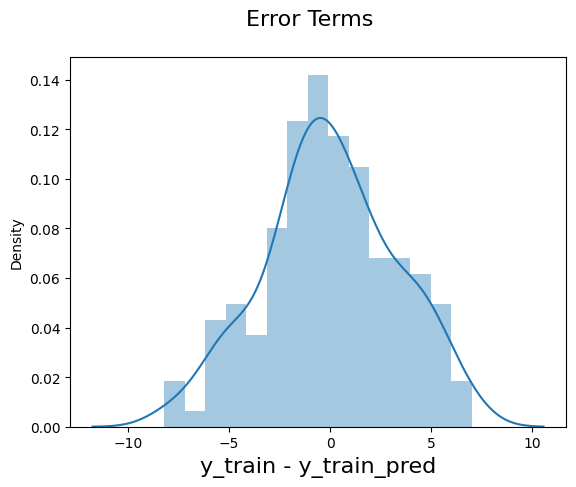

In [21]:
fig = plt.figure()
sns.distplot(res, bins = 15)
fig.suptitle('Error Terms', fontsize = 16)
plt.xlabel('y_train - y_train_pred', fontsize = 16)
plt.show()

## Predictions on the Test Set

In [22]:
x_test_sm = sm.add_constant(x_test)
y_pred = lr.predict(x_test_sm)

In [23]:
y_pred.head()

96     14.717944
16     16.211548
31     20.748197
159     7.664036
129    17.370139
dtype: float64

In [24]:
from sklearn.metrics import mean_squared_error

In [25]:
MSE = mean_squared_error(y_test, y_pred) #Returns mean squared error we will take a square root
MSE

10.204654118800955

In [26]:
np.sqrt(MSE)

np.float64(3.194472431998898)

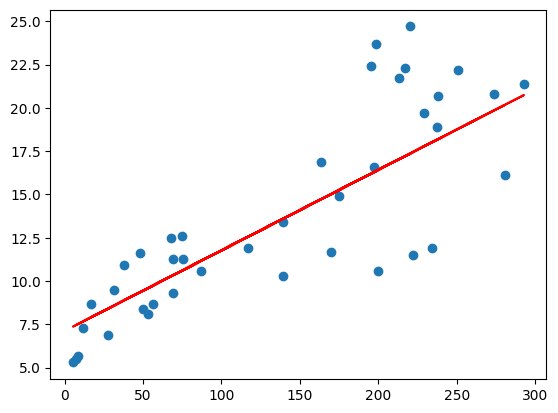

In [36]:
plt.scatter(x_test,y_test)
plt.plot(x_test, 7.1196 + 0.0465*x_test, 'r')
plt.show()